In [1]:
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================

PKL_PATH = "/Users/ais/Desktop/2026_Summer/2d_hippocampal_cells/2D-traj-results-training.pkl"

JSON_PATH = "/Users/ais/Desktop/2026_Summer/2d_hippocampal_cells/grid_cell_scores.json"

# ============================================================
# LOAD PKL
# ============================================================

with open(PKL_PATH, "rb") as f:
    data = pickle.load(f)

# ============================================================
# LOAD JSON
# ============================================================

with open(JSON_PATH, "r") as f:
    grid_results = json.load(f)

print("PKL keys:")
print(data.keys())

print("\nJSON keys:")
print(grid_results.keys())

PKL keys:
dict_keys(['time', 'ground_truth', 'prediction', 'd1', 'z1', 'd2', 'z2', 'd3', 'z3', 'd4'])

JSON keys:
dict_keys(['num_neurons', 'num_grid_cells', 'grid_cell_indices', 'selected_trajectories', 'num_combined_trajectories', 'removed_initial_timesteps', 'random_seed', 'num_shuffles', 'layer_order', 'results'])


In [5]:
from __future__ import annotations

import argparse
import gc
import json
import math
import pickle
import sys
from pathlib import Path
from typing import Dict, List, Mapping, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage, signal


DEFAULT_LAYER_ORDER = (
    "D1",
    "D2",
    "D3",
    "LEC",
    "MEC",
    "graph_LEC",
    "graph_MEC",
)
DEFAULT_NUM_SHUFFLES = 20

try:
    from tqdm import tqdm
except Exception:
    tqdm = None


def matlab_style_gauss2d(shape: Sequence[int], sigma: float) -> np.ndarray:
    """Match MATLAB fspecial('gaussian', shape, sigma)."""
    m, n = [(ss - 1.0) / 2.0 for ss in shape]
    y, x = np.ogrid[-m : m + 1, -n : n + 1]
    h = np.exp(-((x * x + y * y) / (2.0 * sigma * sigma)))
    h[h < np.finfo(h.dtype).eps * h.max()] = 0
    sumh = h.sum()
    if sumh != 0:
        h /= sumh
    return h


def load_pickle(path: Path):
    with path.open("rb") as handle:
        return pickle.load(handle)


def load_trajectory(traj_path: str | Path) -> np.ndarray:
    """Load trajectory and return position array of shape (timesteps, 2)."""
    path = Path(traj_path)
    suffix = path.suffix.lower()

    if suffix in {".pk1", ".pkl", ".pickle"}:
        data = load_pickle(path)
        if not isinstance(data, Mapping):
            raise ValueError(f"Expected trajectory pickle dict, got {type(data)!r}")
        x = np.asarray(data["x"], dtype=float)
        y = np.asarray(data["y"], dtype=float)
        return np.column_stack((x, y))

    if suffix in {".csv", ".txt"}:
        data = np.loadtxt(path, delimiter=",")
        if data.ndim == 1:
            data = data.reshape(1, -1)
        if data.shape[1] < 2:
            raise ValueError("Trajectory CSV must contain at least two columns: x, y")
        return np.asarray(data[:, :2], dtype=float)

    raise ValueError(f"Unsupported trajectory format: {path}")


def align_positions_to_time(pos: np.ndarray, time_len: int) -> np.ndarray:
    """Align position rows to activation timesteps."""
    if len(pos) == time_len:
        return pos
    if len(pos) == time_len + 1:
        return pos[:-1]
    if len(pos) == time_len - 1:
        raise ValueError(
            f"Trajectory is shorter than activations: {len(pos)} vs {time_len}"
        )
    raise ValueError(
        f"Could not align trajectory length {len(pos)} with activation length {time_len}"
    )


def _transpose_if_needed(arr: np.ndarray, time_len: int) -> np.ndarray:
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D activations, got shape {arr.shape}")
    if arr.shape[0] == time_len:
        return arr
    if arr.shape[1] == time_len:
        return arr.T
    raise ValueError(
        f"Could not align activation shape {arr.shape} with trajectory length {time_len}"
    )


def load_activations(
    activations_path: str | Path,
    time_len: int,
    layer_order: Sequence[str] = DEFAULT_LAYER_ORDER,
) -> Tuple[np.ndarray, List[Dict[str, int | str]]]:
    """
    Return activation matrix shaped (timesteps, neurons) and metadata per neuron.

    Supported inputs:
    - pickle dict with layer arrays, matching your `encoded_*.pk1`
    - CSV/TXT of combined activations
    - NPY/NPZ containing a single 2D matrix
    """
    path = Path(activations_path)
    suffix = path.suffix.lower()

    if suffix in {".pk1", ".pkl", ".pickle"}:
        encoded = load_pickle(path)
        if not isinstance(encoded, Mapping):
            raise ValueError(f"Expected activation pickle dict, got {type(encoded)!r}")

        matrices: List[np.ndarray] = []
        neuron_meta: List[Dict[str, int | str]] = []
        global_index = 1

        for layer_name in layer_order:
            if layer_name not in encoded:
                continue
            layer_arr = np.asarray(encoded[layer_name], dtype=float)
            layer_arr = _transpose_if_needed(layer_arr, time_len)
            matrices.append(layer_arr)
            for layer_neuron_idx in range(layer_arr.shape[1]):
                neuron_meta.append(
                    {
                        "global_index": global_index,
                        "layer": layer_name,
                        "layer_neuron_index": layer_neuron_idx + 1,
                    }
                )
                global_index += 1

        if not matrices:
            raise ValueError(
                f"No supported layers found in activation pickle. Looked for: {layer_order}"
            )

        return np.hstack(matrices), neuron_meta

    if suffix in {".csv", ".txt"}:
        arr = np.loadtxt(path, delimiter=",", dtype=float)
    elif suffix == ".npy":
        arr = np.load(path)
    elif suffix == ".npz":
        loaded = np.load(path)
        if len(loaded.files) != 1:
            raise ValueError(
                f"NPZ must contain exactly one array for activations, found {loaded.files}"
            )
        arr = loaded[loaded.files[0]]
    else:
        raise ValueError(f"Unsupported activations format: {path}")

    arr = np.asarray(arr, dtype=float)
    arr = _transpose_if_needed(arr, time_len)
    neuron_meta = [
        {"global_index": idx + 1, "layer": "combined", "layer_neuron_index": idx + 1}
        for idx in range(arr.shape[1])
    ]
    return arr, neuron_meta


def occupancy_map_func(
    pos: np.ndarray,
    reso: int = 40,
    win_len: int = 9,
    sigma: float = 3.0,
) -> np.ndarray:
    hist, _, _ = np.histogram2d(pos[:, 0], pos[:, 1], bins=reso * 2)
    gaussian = matlab_style_gauss2d([win_len, win_len], sigma)
    pos_prob = signal.convolve2d(gaussian, hist)
    trim = int(win_len / 2)
    pos_prob = pos_prob[trim:-trim, trim:-trim]
    pos_prob = pos_prob / np.nansum(pos_prob)
    return pos_prob


def build_firing_rate_map(
    responses: np.ndarray,
    pos: np.ndarray,
    occupancy_map: np.ndarray | None = None,
    thresh_param: float = 1.5,
    res_param: int = 80,
    gaussian_shape: Sequence[int] = (9, 9),
    gaussian_sigma: float = 3.0,
    normalization: str = "occupancy",
) -> Tuple[np.ndarray, List[float]]:
    mean_resp = np.mean(responses)
    std_resp = np.std(responses)
    thresh = mean_resp + (thresh_param * std_resp)
    firing_idx = np.flatnonzero(responses > thresh)

    xmin, xmax = float(np.min(pos[:, 0])), float(np.max(pos[:, 0]))
    ymin, ymax = float(np.min(pos[:, 1])), float(np.max(pos[:, 1]))

    x = np.linspace(xmin, xmax, res_param)
    y = np.linspace(ymin, ymax, res_param)
    firing_map = np.zeros((res_param, res_param), dtype=float)

    if firing_idx.size:
        firing_positions = pos[firing_idx, :2]
        firing_values = responses[firing_idx]

        for ii in range(len(firing_positions)):
            col = int(np.argmin(np.abs(firing_positions[ii, 0] - x)))
            row = int(np.argmin(np.abs(firing_positions[ii, 1] - y)))
            firing_map[row, col] = max(firing_values[ii], firing_map[row, col])

    if normalization == "occupancy" and occupancy_map is not None:
        occ = np.asarray(occupancy_map, dtype=float).copy()
        occ[occ == 0] = np.nan
        with np.errstate(divide="ignore", invalid="ignore"):
            firing_map = np.divide(
                firing_map,
                occ,
                out=np.zeros_like(firing_map, dtype=float),
                where=np.isfinite(occ) & (occ != 0),
            )
        firing_map = np.nan_to_num(firing_map, nan=0.0)
    else:
        max_value = float(np.nanmax(firing_map)) if firing_map.size else 0.0
        if max_value > 0:
            firing_map = firing_map / max_value

    gaussian = matlab_style_gauss2d(gaussian_shape, gaussian_sigma)
    spikes_smooth = signal.convolve2d(gaussian, firing_map)
    trim = int(gaussian_shape[0] // 2)
    spikes_smooth = spikes_smooth[trim:-trim, trim:-trim]
    extent = [xmin, xmax, ymin, ymax]
    return spikes_smooth, extent


def point_corr(
    map1: np.ndarray,
    map2: np.ndarray,
    row_off: int,
    col_off: int,
    bins: int,
) -> float:
    num_rows = bins - abs(row_off)
    num_cols = bins - abs(col_off)

    if row_off > 0:
        r_st1 = abs(row_off)
        r_st2 = 0
    else:
        r_st1 = 0
        r_st2 = abs(row_off)

    if col_off > 0:
        c_st1 = abs(col_off)
        c_st2 = 0
    else:
        c_st1 = 0
        c_st2 = abs(col_off)

    block1 = map1[r_st1 : r_st1 + num_rows, c_st1 : c_st1 + num_cols]
    block2 = map2[r_st2 : r_st2 + num_rows, c_st2 : c_st2 + num_cols]
    valid = ~np.isnan(block1) & ~np.isnan(block2)
    nb = int(valid.sum())
    if nb < 20:
        return 0.0

    x = block1[valid]
    y = block2[valid]
    sum_x = x.sum()
    sum_y = y.sum()
    sum_xy = np.sum(x * y)
    sum_x2 = np.sum(x * x)
    sum_y2 = np.sum(y * y)

    var_x = sum_x2 - (sum_x * sum_x) / nb
    var_y = sum_y2 - (sum_y * sum_y) / nb
    cov_xy = sum_xy - (sum_x * sum_y) / nb

    if (var_x <= 0 <= var_y) or (var_y <= 0 <= var_x):
        return 0.0
    if var_x <= 0 or var_y <= 0:
        return 0.0

    return float(cov_xy / math.sqrt(var_x * var_y))


def correlation_map(map1: np.ndarray, map2: np.ndarray) -> np.ndarray:
    bins = map1.shape[0]
    n = bins + round(0.64 * bins)
    if n % 2 == 0:
        n -= 1
    center_bin = (n + 1) // 2

    corr = np.zeros((n, n), dtype=float)
    for ii in range(n):
        row_off = ii + 1 - center_bin
        for jj in range(n):
            col_off = jj + 1 - center_bin
            corr[ii, jj] = point_corr(map1, map2, row_off, col_off, bins)
    return corr


def _crop_center(rotated: np.ndarray, target_shape: Tuple[int, int]) -> np.ndarray:
    start0 = (rotated.shape[0] - target_shape[0]) // 2
    start1 = (rotated.shape[1] - target_shape[1]) // 2
    return rotated[start0 : start0 + target_shape[0], start1 : start1 + target_shape[1]]


def corrcoef2(a: np.ndarray, b: np.ndarray) -> float:
    a_flat = np.asarray(a, dtype=float).ravel()
    b_flat = np.asarray(b, dtype=float).ravel()
    valid = ~np.isnan(a_flat) & ~np.isnan(b_flat)
    if valid.sum() < 2:
        return 0.0
    a_flat = a_flat[valid]
    b_flat = b_flat[valid]
    if np.std(a_flat) == 0 or np.std(b_flat) == 0:
        return 0.0
    return float(np.corrcoef(a_flat, b_flat)[0, 1])


def gridscore(masked_corr: np.ndarray) -> float:
    c60 = ndimage.rotate(masked_corr, 60, reshape=True)
    c60_2 = _crop_center(c60, masked_corr.shape)
    r60 = corrcoef2(masked_corr, c60_2)

    c120 = ndimage.rotate(masked_corr, 120, reshape=True)
    c120_2 = _crop_center(c120, masked_corr.shape)
    r120 = corrcoef2(masked_corr, c120_2)

    c30 = ndimage.rotate(masked_corr, 30, reshape=True)
    c30_2 = _crop_center(c30, masked_corr.shape)
    r30 = corrcoef2(masked_corr, c30_2)

    c90 = ndimage.rotate(masked_corr, 90, reshape=False)
    r90 = corrcoef2(masked_corr, c90)

    c150 = ndimage.rotate(masked_corr, 150, reshape=True)
    c150_2 = _crop_center(c150, masked_corr.shape)
    r150 = corrcoef2(masked_corr, c150_2)

    return float(min(r60, r120) - max(r30, r90, r150))


def _regional_maxima(arr: np.ndarray) -> np.ndarray:
    max_filtered = ndimage.maximum_filter(arr, size=3, mode="nearest")
    return (arr == max_filtered) & np.isfinite(arr)


def get_original_grid_score(spikes_smooth: np.ndarray, win_len: int = 7) -> float:
    rotated_img = ndimage.rotate(spikes_smooth, 90, reshape=True)
    trim = round(win_len / 2)
    rotated_img = rotated_img[trim:-trim, trim:-trim]

    corr = correlation_map(rotated_img, rotated_img)
    rows, cols = corr.shape
    central_peak = np.array([0.5 * (rows + 1), 0.5 * (cols + 1)], dtype=float)

    maxima = _regional_maxima(corr)
    peakx, peaky = np.where(maxima)
    if peakx.size == 0:
        return float("nan")

    peak_matrix = np.column_stack((peakx + 1, peaky + 1))
    distances = np.linalg.norm(peak_matrix - central_peak, axis=1)
    distascending = np.sort(distances)
    if len(distascending) < 6:
        return float("nan")

    radius1 = np.max(distascending[1 : min(6, len(distascending))]) + 3
    rr, cc = np.meshgrid(np.arange(1, len(corr) + 1), np.arange(1, len(corr) + 1))
    circlemask1 = np.sqrt((rr - central_peak[0]) ** 2 + (cc - central_peak[1]) ** 2) <= radius1
    corr_ring = corr * circlemask1

    radius2 = 12
    circlemask2 = np.sqrt((rr - central_peak[0]) ** 2 + (cc - central_peak[1]) ** 2) <= radius2
    corr_ring = corr_ring * (~circlemask2)

    return gridscore(corr_ring)


def build_autocorrelation_ring(
    spikes_smooth: np.ndarray,
    win_len: int = 7,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    rotated_img = ndimage.rotate(spikes_smooth, 90, reshape=True)
    trim = round(win_len / 2)
    rotated_img = rotated_img[trim:-trim, trim:-trim]

    corr = correlation_map(rotated_img, rotated_img)
    rows, cols = corr.shape
    central_peak = np.array([0.5 * (rows + 1), 0.5 * (cols + 1)], dtype=float)

    maxima = _regional_maxima(corr)
    peakx, peaky = np.where(maxima)
    if peakx.size == 0:
        return corr, corr, rotated_img

    peak_matrix = np.column_stack((peakx + 1, peaky + 1))
    distances = np.linalg.norm(peak_matrix - central_peak, axis=1)
    distascending = np.sort(distances)
    if len(distascending) < 6:
        return corr, corr, rotated_img

    radius1 = np.max(distascending[1 : min(6, len(distascending))]) + 3
    rr, cc = np.meshgrid(np.arange(1, len(corr) + 1), np.arange(1, len(corr) + 1))
    circlemask1 = np.sqrt((rr - central_peak[0]) ** 2 + (cc - central_peak[1]) ** 2) <= radius1
    corr_ring = corr * circlemask1

    radius2 = 12
    circlemask2 = np.sqrt((rr - central_peak[0]) ** 2 + (cc - central_peak[1]) ** 2) <= radius2
    corr_ring = corr_ring * (~circlemask2)
    return corr, corr_ring, rotated_img


def score_single_neuron(
    responses: np.ndarray,
    pos: np.ndarray,
    occupancy_map: np.ndarray,
    num_shuffles: int,
    rng: np.random.Generator,
    thresh_param: float,
    res_param: int,
) -> Dict[str, object]:
    map_res = int(occupancy_map.shape[0]) if occupancy_map is not None else res_param
    original_map, original_extent = build_firing_rate_map(
        responses,
        pos,
        occupancy_map,
        thresh_param=thresh_param,
        res_param=map_res,
    )
    autocorr_map, autocorr_ring, _ = build_autocorrelation_ring(original_map)
    original_hgs = gridscore(autocorr_ring)

    shuffled_scores = np.zeros(num_shuffles, dtype=float)
    for shuffle_idx in range(num_shuffles):
        shuffled_resp = rng.permutation(responses)
        shuffled_map, _ = build_firing_rate_map(
            shuffled_resp,
            pos,
            occupancy_map,
            thresh_param=thresh_param,
            res_param=map_res,
        )
        _, shuffled_ring, _ = build_autocorrelation_ring(shuffled_map)
        shuffled_scores[shuffle_idx] = gridscore(shuffled_ring)

    threshold_95 = float(np.nanpercentile(shuffled_scores, 95))
    is_grid = bool(np.isfinite(original_hgs) and original_hgs > threshold_95)

    return {
        "original_hgs": float(original_hgs),
        "shuffle_threshold_95": threshold_95,
        "is_grid_cell": is_grid,
        "shuffled_hgs": shuffled_scores,
        "original_map": original_map,
        "original_extent": original_extent,
        "autocorr_map": autocorr_map,
        "autocorr_ring": autocorr_ring,
    }


def save_neuron_plots(
    output_dir: str | Path,
    neuron_filename: str,
    layer_name: str,
    global_index: int,
    layer_neuron_index: int,
    firing_map: np.ndarray,
    firing_extent: Sequence[float],
    autocorr_map: np.ndarray,
    hgs: float,
    threshold_95: float,
    is_grid: bool,
) -> None:
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    rotated = ndimage.rotate(firing_map, 90)
    rotated_extent = [firing_extent[2], firing_extent[3], firing_extent[0], firing_extent[1]]
    axes[0].imshow(
        rotated,
        origin="lower",
        cmap="jet",
        aspect="auto",
        extent=rotated_extent,
    )
    axes[0].set_title(f"{layer_name} #{layer_neuron_index} firing map")
    axes[0].axis("off")

    axes[1].imshow(autocorr_map, origin="lower", cmap="coolwarm", aspect="auto")
    axes[1].set_title(
        f"global #{global_index} autocorr\nHGS={hgs:.3f}, thr95={threshold_95:.3f}, grid={is_grid}"
    )
    axes[1].axis("off")

    fig.tight_layout()
    fig.savefig(output_path / f"{neuron_filename}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)


def score_grid_cells(
    activations_path: str | Path,
    trajectory_path: str | Path,
    num_shuffles: int = DEFAULT_NUM_SHUFFLES,
    thresh_param: float = 1.5,
    res_param: int = 40,
    random_seed: int = 0,
    plots_dir: str | Path | None = None,
    checkpoint_output_path: str | Path | None = None,
) -> Dict[str, object]:
    raw_pos = load_trajectory(trajectory_path)
    activations, neuron_meta = load_activations(activations_path, time_len=len(raw_pos) - 1 if len(raw_pos) > 1 else len(raw_pos))
    pos = align_positions_to_time(raw_pos, activations.shape[0])
    occupancy_map = occupancy_map_func(pos, reso=res_param)
    rng = np.random.default_rng(random_seed)

    results: List[Dict[str, object]] = []
    grid_indices: List[int] = []
    total_neurons = activations.shape[1]
    iterator = range(total_neurons)
    if tqdm is not None:
        iterator = tqdm(iterator, total=total_neurons, desc="Scoring neurons", unit="neuron")

    for neuron_idx in iterator:
        neuron_result = score_single_neuron(
            activations[:, neuron_idx],
            pos,
            occupancy_map,
            num_shuffles=num_shuffles,
            rng=rng,
            thresh_param=thresh_param,
            res_param=res_param,
        )
        meta = dict(neuron_meta[neuron_idx])
        meta.update(neuron_result)
        meta["shuffled_hgs"] = np.asarray(meta["shuffled_hgs"], dtype=float).tolist()
        neuron_prefix = "grid_neuron" if bool(meta["is_grid_cell"]) else "neuron"
        neuron_filename = f"{neuron_prefix}_{int(meta['global_index']):03d}"
        if plots_dir is not None:
            layer_plot_dir = Path(plots_dir) / str(meta["layer"])
            save_neuron_plots(
                layer_plot_dir,
                neuron_filename,
                str(meta["layer"]),
                int(meta["global_index"]),
                int(meta["layer_neuron_index"]),
                np.asarray(meta["original_map"], dtype=float),
                list(meta["original_extent"]),
                np.asarray(meta["autocorr_map"], dtype=float),
                float(meta["original_hgs"]),
                float(meta["shuffle_threshold_95"]),
                bool(meta["is_grid_cell"]),
            )
        meta["plot_filename"] = f"{str(meta['layer'])}/{neuron_filename}.png"
        meta.pop("original_map", None)
        meta.pop("original_extent", None)
        meta.pop("autocorr_map", None)
        meta.pop("autocorr_ring", None)
        results.append(meta)

        if bool(meta["is_grid_cell"]):
            grid_indices.append(int(meta["global_index"]))

        if checkpoint_output_path is not None:
            save_results(
                checkpoint_output_path,
                {
                    "grid_cell_indices": grid_indices,
                    "results": results,
                    "num_neurons": int(activations.shape[1]),
                    "num_grid_cells": int(len(grid_indices)),
                    "num_shuffles": int(num_shuffles),
                    "completed_neurons": int(neuron_idx + 1),
                },
            )

        del neuron_result
        del meta
        gc.collect()

        if tqdm is None:
            progress = ((neuron_idx + 1) / total_neurons) * 100.0
            print(
                f"\rScoring neurons: {neuron_idx + 1}/{total_neurons} ({progress:.1f}%)",
                end="",
                flush=True,
            )

    if tqdm is None and total_neurons:
        print()

    return {
        "grid_cell_indices": grid_indices,
        "results": results,
        "num_neurons": int(activations.shape[1]),
        "num_grid_cells": int(len(grid_indices)),
        "num_shuffles": int(num_shuffles),
    }


def save_results(output_path: str | Path, payload: Mapping[str, object]) -> None:
    path = Path(output_path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2)


def ensure_output_dirs(
    output_path: str | Path,
    plots_dir: str | Path | None,
    layer_names: Sequence[str] = DEFAULT_LAYER_ORDER,
) -> None:
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    if plots_dir is None:
        return
    plots_root = Path(plots_dir)
    plots_root.mkdir(parents=True, exist_ok=True)
    for layer_name in layer_names:
        (plots_root / layer_name).mkdir(parents=True, exist_ok=True)


def default_output_paths(
    activations_path: str | Path,
    root_dir: str | Path | None = None,
) -> Tuple[Path, Path]:
    if root_dir is None:
        root_dir = Path(__file__).resolve().parent.parent / "spatial cell results"
    activation_stem = Path(activations_path).stem
    prefixes = ("encoded_ec_hpc_", "encoded_")
    run_name = activation_stem
    for prefix in prefixes:
        if activation_stem.startswith(prefix):
            run_name = activation_stem[len(prefix) :]
            break
    if run_name.endswith("_30epochs"):
        run_name = run_name[: -len("_30epochs")]

    run_dir = Path(root_dir) / run_name
    json_path = run_dir / "grid cells" / "grid_cell_scores.json"
    plots_dir = run_dir / "firing rate maps"
    return json_path, plots_dir

In [56]:
# ============================================================================
# GRID CELL FUNCTIONS  (delegated to grid_cell_scorer.py)
# ============================================================================

def firing_rate_map_grid(ot, all_dat, occupancy_map, thresh_param=1.5, res_param=40):
    """Generate firing rate map for grid cell analysis using the canonical scorer."""
    map_res = int(occupancy_map.shape[0]) if occupancy_map is not None else res_param
    spikes_smooth, extent = build_firing_rate_map(
        responses=ot,
        pos=all_dat,
        occupancy_map=occupancy_map,
        thresh_param=thresh_param,
        res_param=map_res,
    )
    return spikes_smooth, extent


def detect_grid_cells(pos_out, encoded_data, lim=1.5, reso=40, num_shuffles=20, random_seed=0):
    """
    Detect grid cells using HGS with shuffle-based significance test.
    Returns:
        grid_cells       — list of 1-based global neuron indices
        autocorr_data    — dict mapping global_index -> {autocorr_map, autocorr_ring, hgs, threshold_95, layer, neuron_within_layer}
    """
    layer_order = ('D1', 'D2', 'D3', 'LEC', 'MEC', 'graph_LEC', 'graph_MEC')
    occupancy_map = occupancy_map_func(pos_out, reso=reso)
    rng = np.random.default_rng(random_seed)

    grid_cells = []
    autocorr_data = {}
    global_index = 1

    for layer_name in layer_order:
        if layer_name not in encoded_data:
            continue
        layer_arr = np.asarray(encoded_data[layer_name], dtype=float)
        n_neurons = layer_arr.shape[1]  # shape is (timesteps, neurons)

        for neuron_idx in range(n_neurons):
            result = score_single_neuron(
                responses=layer_arr[:, neuron_idx],
                pos=pos_out,
                occupancy_map=occupancy_map,
                num_shuffles=num_shuffles,
                rng=rng,
                thresh_param=lim,
                res_param=reso,
            )
            if result['is_grid_cell']:
                grid_cells.append(global_index)
                autocorr_data[global_index] = {
                    'autocorr_map':  result['autocorr_map'],
                    'autocorr_ring': result['autocorr_ring'],
                    'hgs':           result['original_hgs'],
                    'threshold_95':  result['shuffle_threshold_95'],
                    'layer':         layer_name,
                    'neuron_within_layer': neuron_idx + 1,
                }
            global_index += 1

    return grid_cells, autocorr_data

In [57]:
# ============================================================
# REBUILD THE DATA USED FOR GRID CELL DETECTION
# ============================================================

REMOVE_FIRST = grid_results["removed_initial_timesteps"]
selected_traj = grid_results["selected_trajectories"]

print(f"Selected trajectories: {selected_traj}")
print(f"Removing first {REMOVE_FIRST} timesteps")

# ------------------------------------------------------------
# COMBINED TRAJECTORY
# ------------------------------------------------------------

trajectory = np.concatenate(
    [
        data["ground_truth"][traj, REMOVE_FIRST:, :]
        for traj in selected_traj
    ],
    axis=0,
)

# ------------------------------------------------------------
# COMBINED ACTIVATIONS
# ------------------------------------------------------------

layer_order = [
    "d1",
    "z1",
    "d2",
    "z2",
    "d3",
    "z3",
    "d4",
]

encoded_data = {}

for layer in layer_order:

    encoded_data[layer] = np.concatenate(
        [
            data[layer][traj, REMOVE_FIRST:, :]
            for traj in selected_traj
        ],
        axis=0,
    )

print("\nCombined trajectory shape:")
print(trajectory.shape)

print("\nCombined activation shapes:")
for layer in layer_order:
    print(f"{layer:>3}: {encoded_data[layer].shape}")

Selected trajectories: [44, 216, 219, 325, 384]
Removing first 50 timesteps

Combined trajectory shape:
(2250, 2)

Combined activation shapes:
 d1: (2250, 100)
 z1: (2250, 100)
 d2: (2250, 100)
 z2: (2250, 100)
 d3: (2250, 100)
 z3: (2250, 100)
 d4: (2250, 100)


In [58]:
# ============================================================
# CONVERT COMPLEX ACTIVATIONS TO MAGNITUDE
# ============================================================

for layer in layer_order:

    if np.iscomplexobj(encoded_data[layer]):

        print(f"Converting {layer} from complex -> magnitude")

        encoded_data[layer] = np.abs(encoded_data[layer])

print("\nData types after conversion:")

for layer in layer_order:
    print(layer, encoded_data[layer].dtype)

Converting d1 from complex -> magnitude
Converting z1 from complex -> magnitude
Converting d2 from complex -> magnitude
Converting z2 from complex -> magnitude
Converting d3 from complex -> magnitude
Converting z3 from complex -> magnitude

Data types after conversion:
d1 float32
z1 float32
d2 float32
z2 float32
d3 float32
z3 float32
d4 float32


Occupancy map shape: (80, 80)


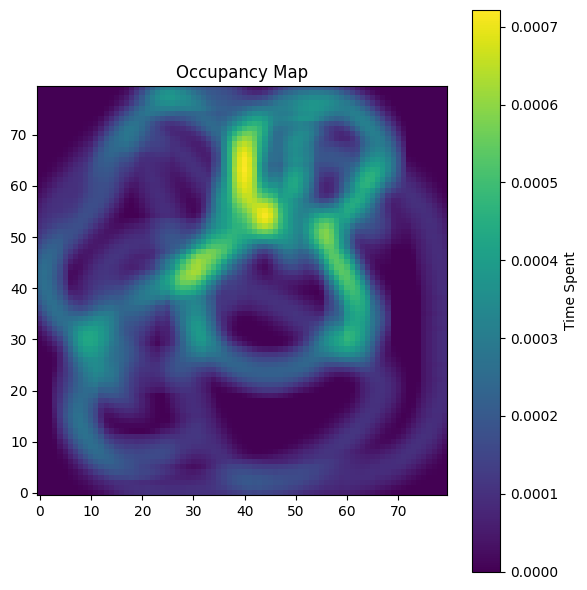

In [59]:
# ============================================================
# BUILD OCCUPANCY MAP
# ============================================================

RESOLUTION = 40      # Use the same resolution as the original grid-cell scorer

occupancy_map = occupancy_map_func(
    trajectory,
    reso=RESOLUTION,
)

print("Occupancy map shape:", occupancy_map.shape)

plt.figure(figsize=(6,6))

plt.imshow(
    occupancy_map,
    origin="lower",
    cmap="viridis",
)

plt.title("Occupancy Map")
plt.colorbar(label="Time Spent")

plt.tight_layout()
plt.show()

In [60]:
# ============================================================
# BUILD LOOKUP TABLE FROM JSON
# ============================================================

# Mapping from original scorer layer names -> your model layers
layer_map = {
    "D1": "d1",
    "LEC": "z1",
    "D2": "d2",
    "MEC": "z2",
    "D3": "d3",
    "graph_LEC": "z3",
    "graph_MEC": "d4",
}

lookup = {}

for result in grid_results["results"]:

    lookup[result["global_index"]] = {

        "layer": layer_map[result["layer"]],

        # convert to 0-based indexing
        "neuron_idx": result["layer_neuron_index"] - 1,

        "hgs": result["original_hgs"],

        "threshold": result["shuffle_threshold_95"],

        "is_grid": result["is_grid_cell"],
    }

print(f"Lookup table contains {len(lookup)} neurons.")
print(f"Detected grid cells: {len(grid_results['grid_cell_indices'])}")

# Show one example
example = grid_results["grid_cell_indices"][0]

print("\nExample:")
print("Global neuron:", example)
print(lookup[example])

Lookup table contains 700 neurons.
Detected grid cells: 52

Example:
Global neuron: 14
{'layer': 'd1', 'neuron_idx': 13, 'hgs': -0.0573707957043158, 'threshold': -0.08921048686703786, 'is_grid': True}


In [61]:
info = lookup[14]

responses = encoded_data[
    info["layer"]
][:, info["neuron_idx"]]

{'layer': 'd1', 'neuron_idx': 13, 'hgs': -0.0573707957043158, 'threshold': -0.08921048686703786, 'is_grid': True}
Responses: (2250,)
Trajectory: (2250, 2)
Occupancy: (80, 80)
Firing map: (80, 80)


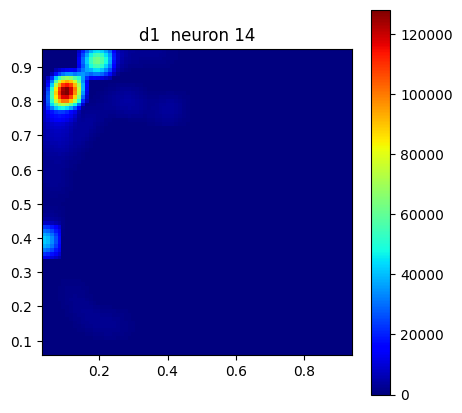

In [62]:
# ============================================================
# PLOT ONE GRID CELL
# ============================================================

global_idx = grid_results["grid_cell_indices"][0]

info = lookup[global_idx]

print(info)

responses = encoded_data[
    info["layer"]
][:, info["neuron_idx"]]

print("Responses:", responses.shape)
print("Trajectory:", trajectory.shape)
print("Occupancy:", occupancy_map.shape)

# ------------------------------------------------------------
# FIRING RATE MAP
# ------------------------------------------------------------

firing_map, extent = firing_rate_map_grid(
    ot=responses,
    all_dat=trajectory,
    occupancy_map=occupancy_map,
    thresh_param=1.5,
)

print("Firing map:", firing_map.shape)

plt.figure(figsize=(5,5))

plt.imshow(
    firing_map,
    origin="lower",
    extent=extent,
    cmap="jet",
)

plt.title(
    f"{info['layer']}  neuron {info['neuron_idx']+1}"
)

plt.colorbar()

plt.show()

In [63]:
#inspection

print("Responses")

print("Min :", np.min(responses))
print("Max :", np.max(responses))
print("Mean:", np.mean(responses))
print("Std :", np.std(responses))

threshold = np.mean(responses) + 1.5*np.std(responses)

print("\nThreshold:", threshold)

print("Number above threshold:",
      np.sum(responses > threshold))

Responses
Min : 0.015436532
Max : 7.37973
Mean: 0.6975603
Std : 0.8420014

Threshold: 1.960562378168106
Number above threshold: 207


207


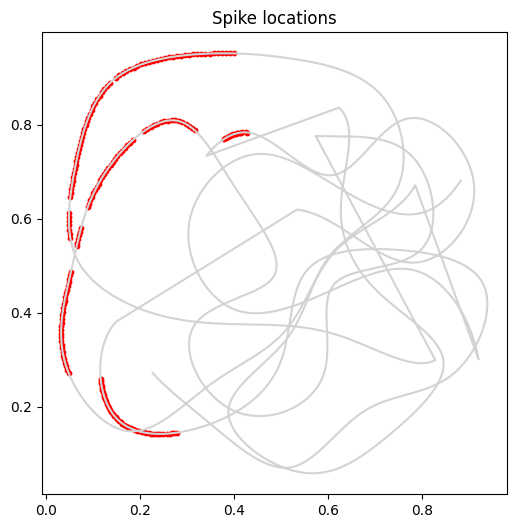

In [64]:
spike_idx = np.where(responses > threshold)[0]

print(len(spike_idx))

plt.figure(figsize=(6,6))

plt.plot(
    trajectory[:,0],
    trajectory[:,1],
    color="lightgray",
)

plt.scatter(
    trajectory[spike_idx,0],
    trajectory[spike_idx,1],
    c="red",
    s=10,
)

plt.axis("equal")
plt.title("Spike locations")
plt.show()

Autocorrelation shape: (117, 117)


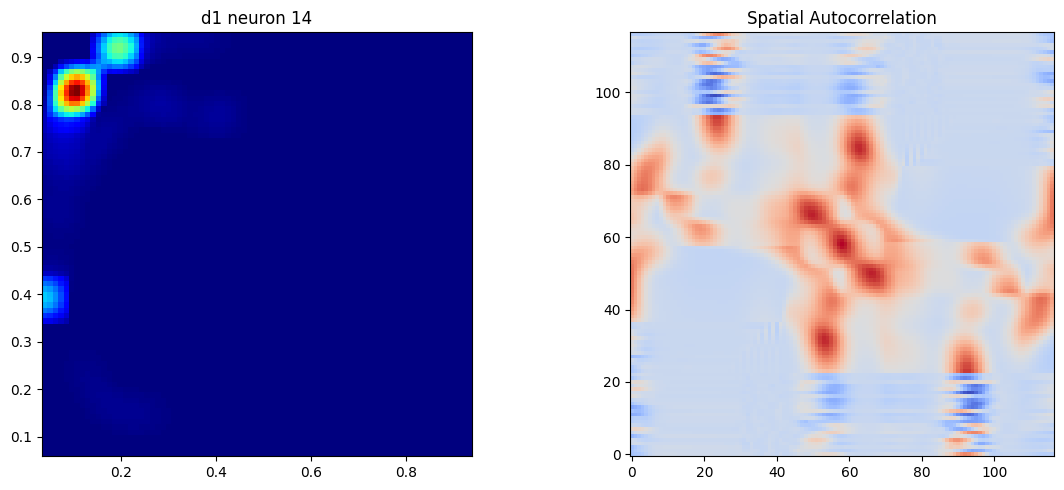

In [65]:
# ============================================================
# BUILD AUTOCORRELATION MAP
# ============================================================

# Use the firing map from the previous cell

autocorr_map, autocorr_ring, radius = build_autocorrelation_ring(
    firing_map
)

print("Autocorrelation shape:", autocorr_map.shape)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# ------------------------------------------------------------
# Firing Rate Map
# ------------------------------------------------------------

ax[0].imshow(
    firing_map,
    origin="lower",
    extent=extent,
    cmap="jet",
)

ax[0].set_title(
    f"{info['layer']} neuron {info['neuron_idx']+1}"
)

# ------------------------------------------------------------
# Spatial Autocorrelation
# ------------------------------------------------------------

ax[1].imshow(
    autocorr_map,
    origin="lower",
    cmap="coolwarm",
)

ax[1].set_title("Spatial Autocorrelation")

plt.tight_layout()
plt.show()

In [66]:
grid_score = gridscore(autocorr_ring)

print(grid_score)

-0.063570447667188


In [67]:
results = sorted(
    grid_results["results"],
    key=lambda x: x["original_hgs"],
    reverse=True,
)

for r in results[:10]:
    print(
        f"HGS={r['original_hgs']:.3f}",
        r["layer"],
        r["layer_neuron_index"],
    )

HGS=0.767 D2 58
HGS=0.646 D3 55
HGS=0.619 D2 79
HGS=0.546 D3 5
HGS=0.487 MEC 57
HGS=0.456 D2 36
HGS=0.426 graph_MEC 69
HGS=0.413 graph_MEC 2
HGS=0.400 D3 79
HGS=0.392 D2 64


In [68]:
# ============================================================
# RUN GRID CELL DETECTION
# ============================================================

grid_cells, autocorr_data = detect_grid_cells(
    pos_out=trajectory,
    encoded_data=encoded_data,
    lim=1.5,
    reso=occupancy_map.shape[0],      # use the same resolution as the occupancy map
    num_shuffles=20,
    random_seed=0,
)

print("=" * 60)
print(f"Detected {len(grid_cells)} grid cells")
print("=" * 60)

print("First few detected neurons:")
print(grid_cells[:10])

Detected 0 grid cells
First few detected neurons:
[]


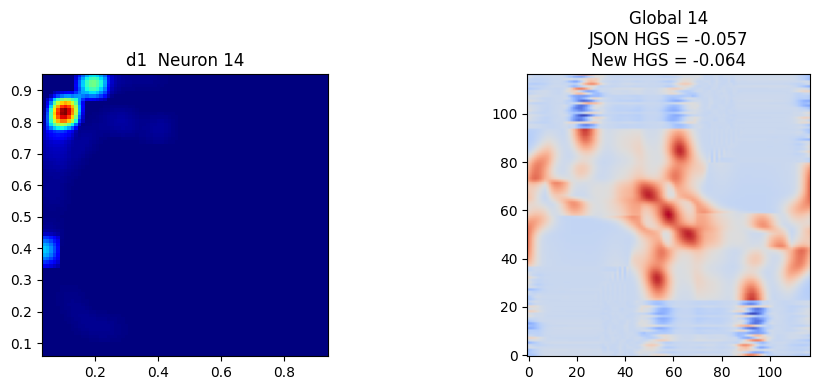

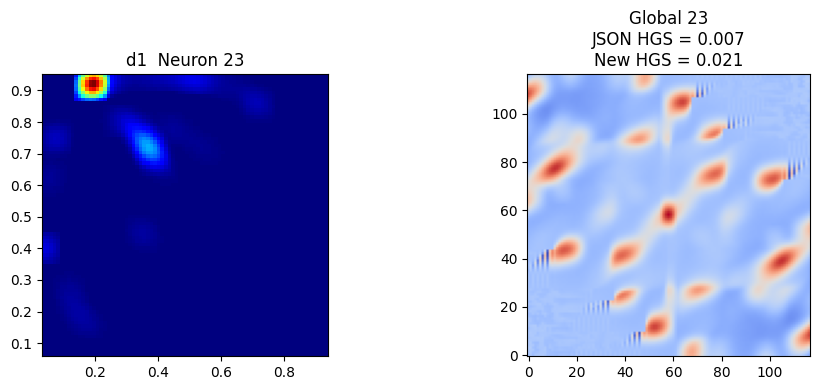

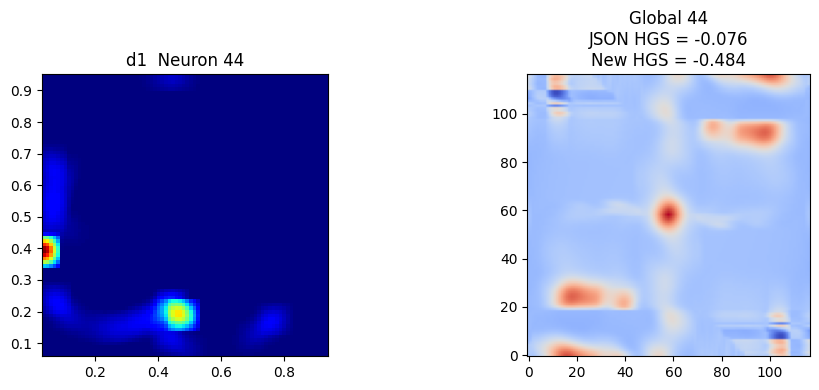

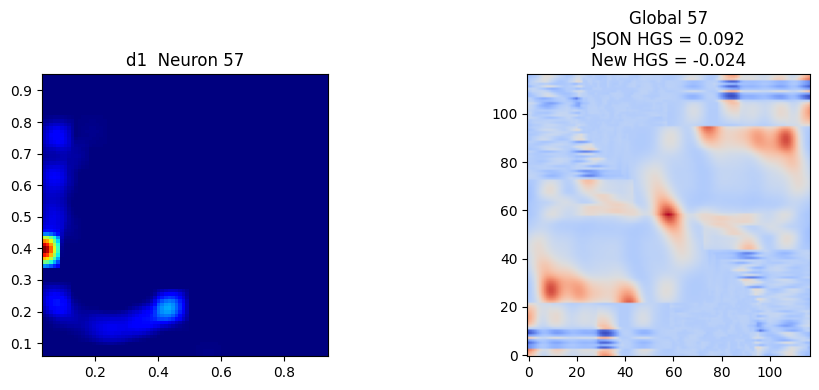

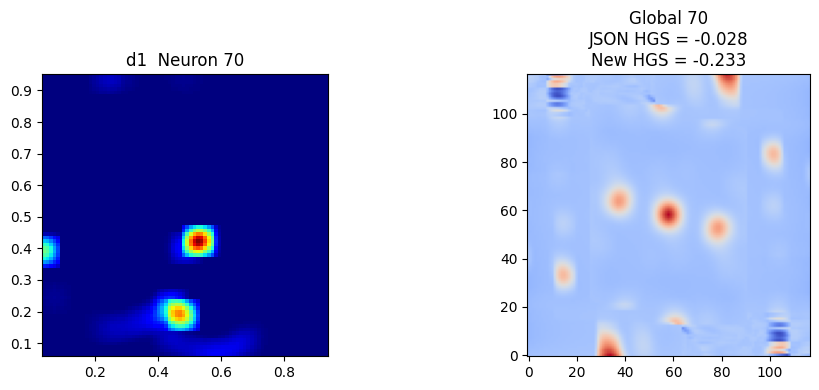

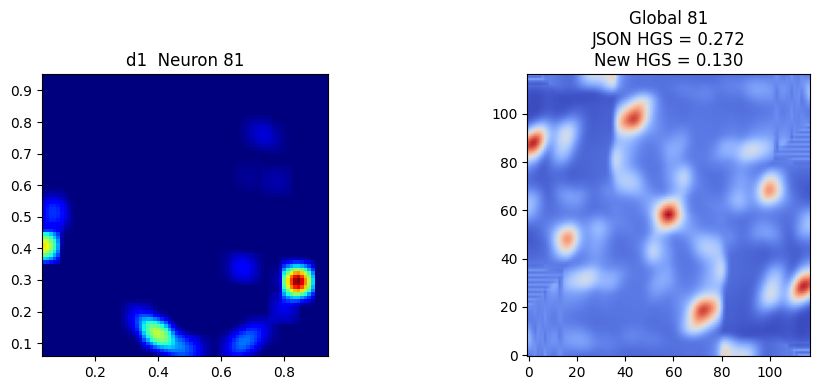

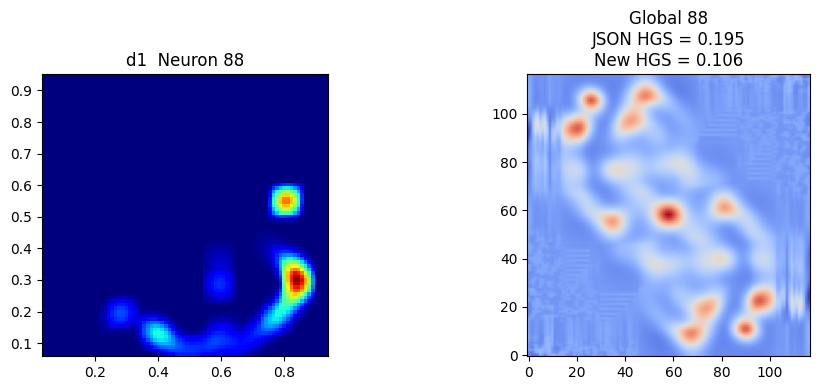

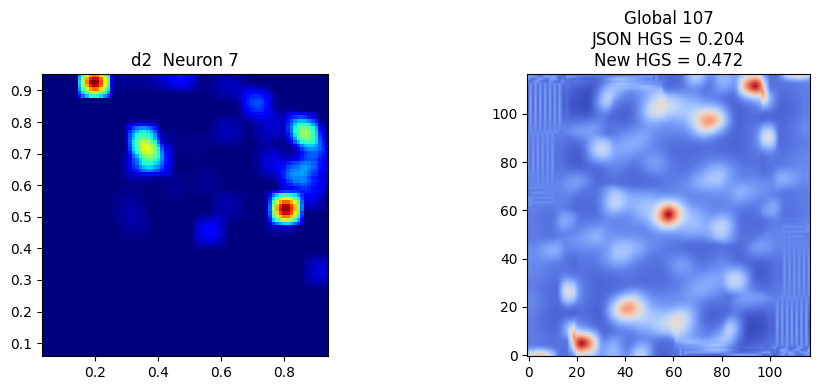

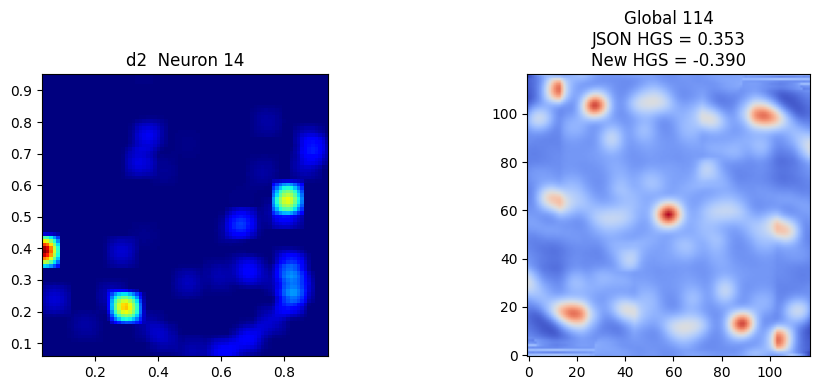

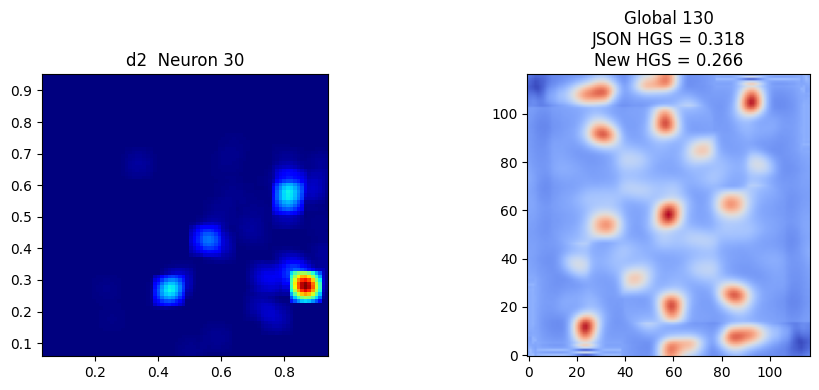

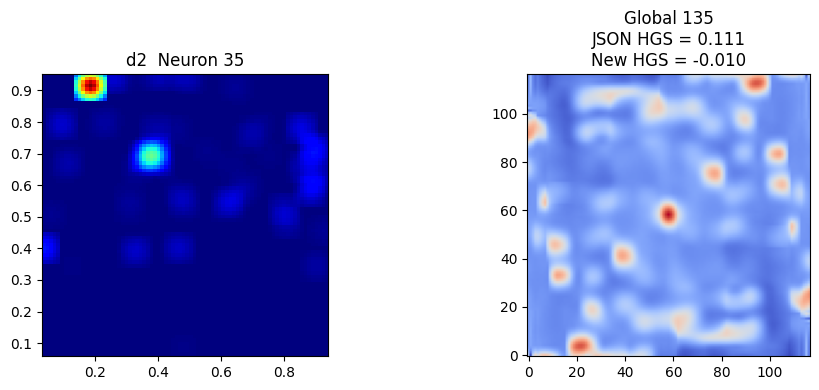

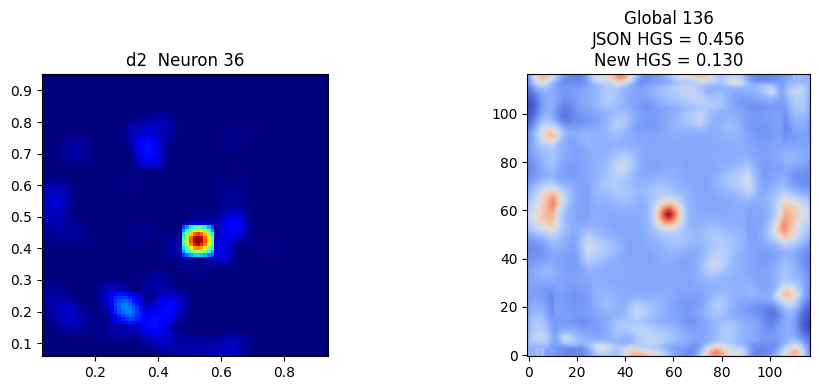

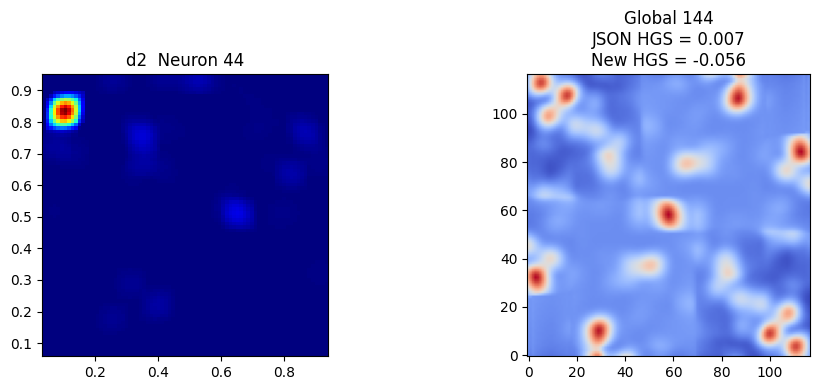

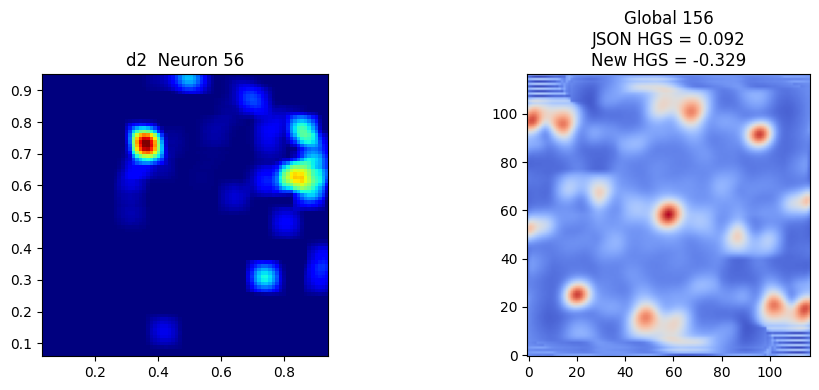

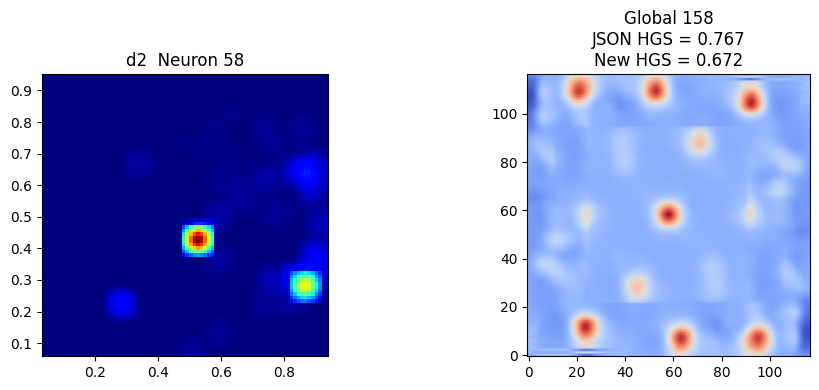

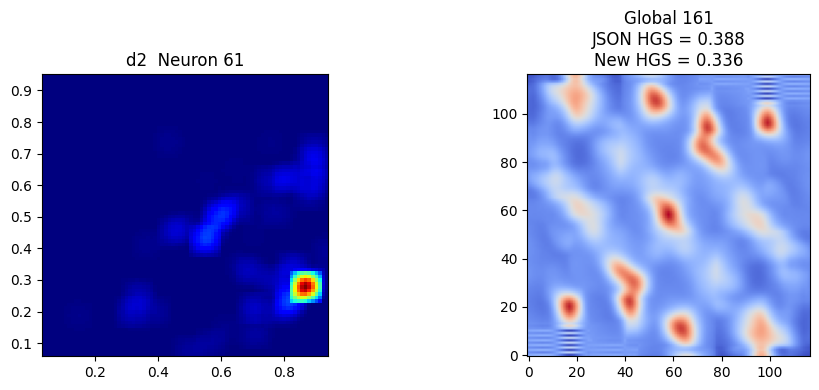

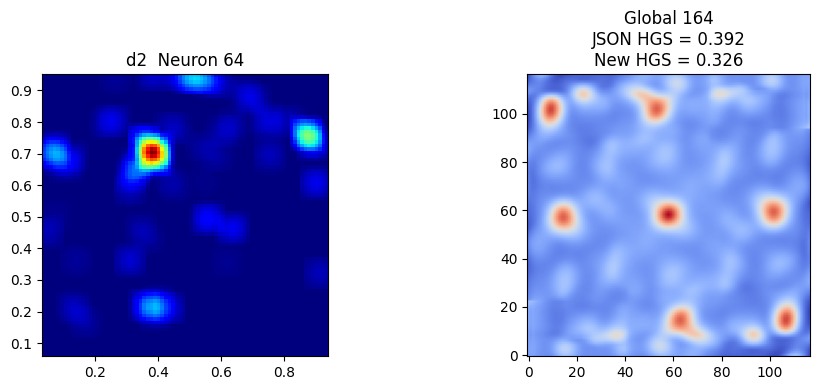

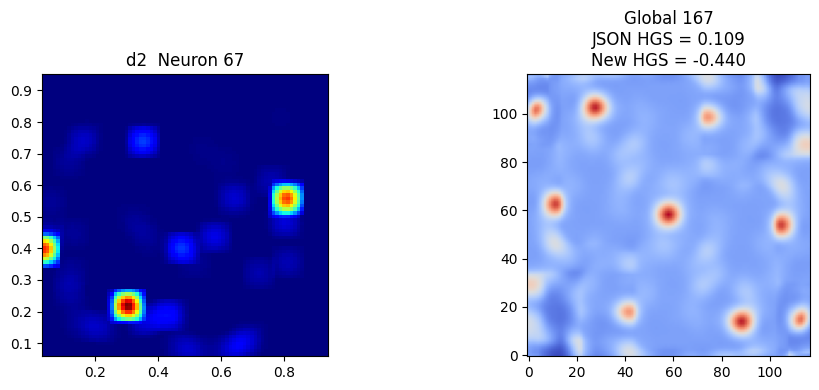

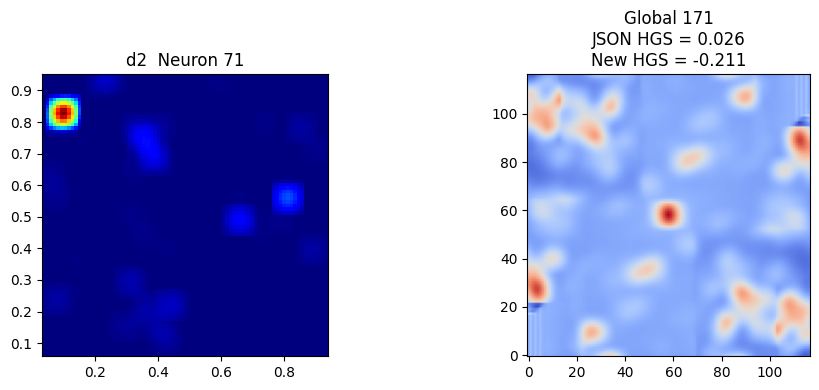

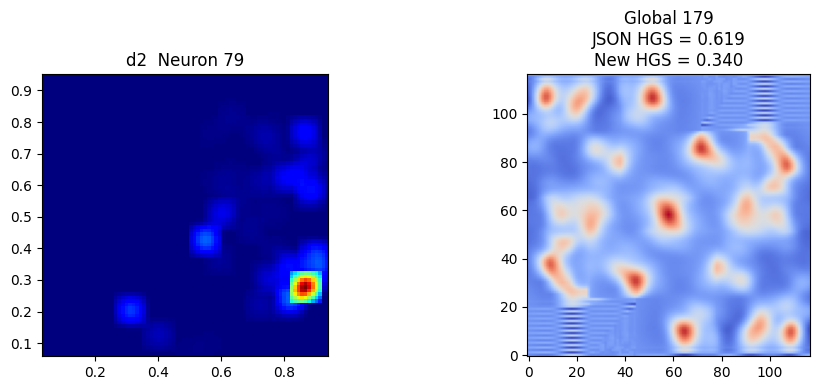

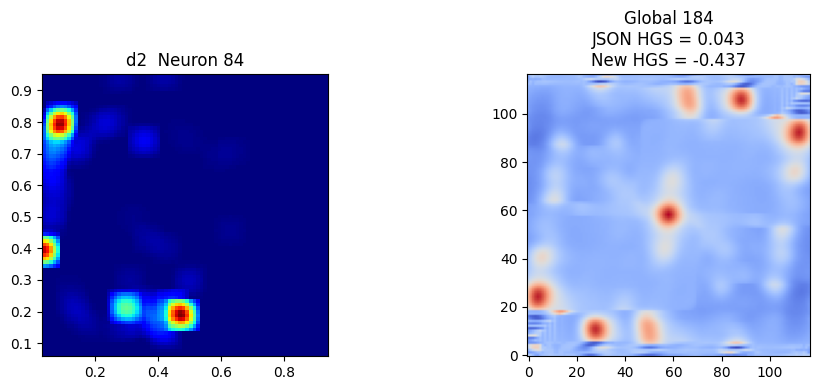

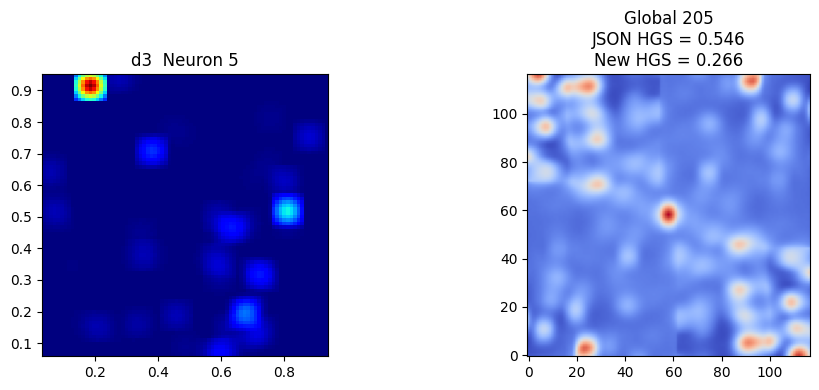

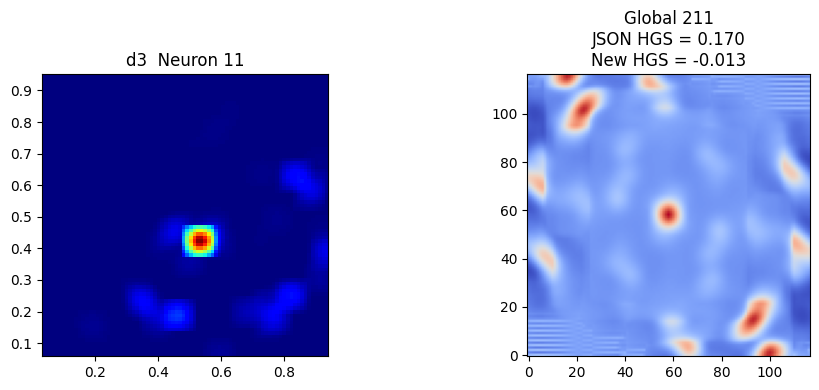

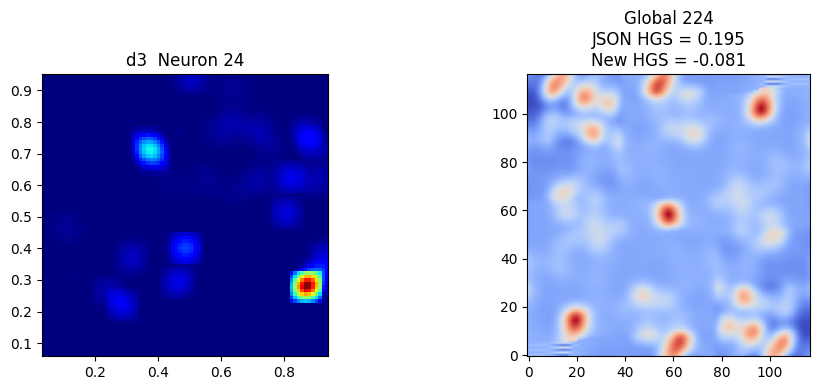

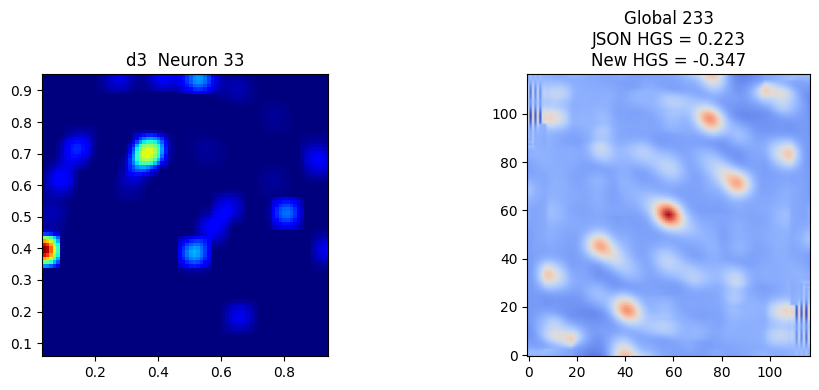

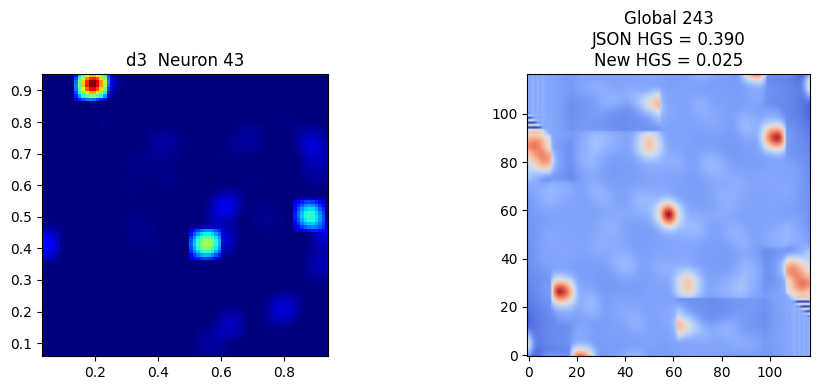

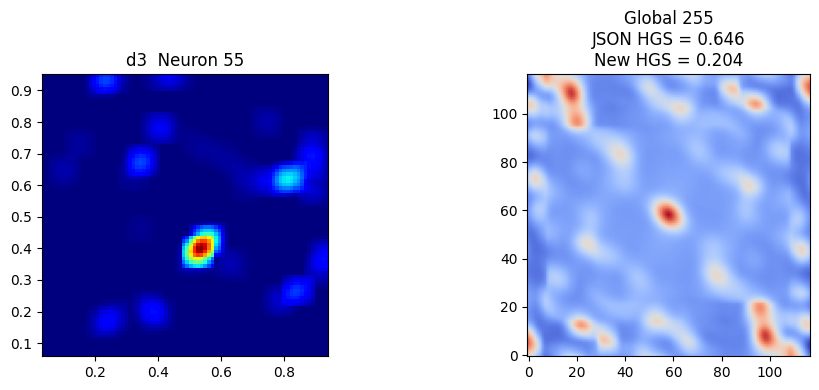

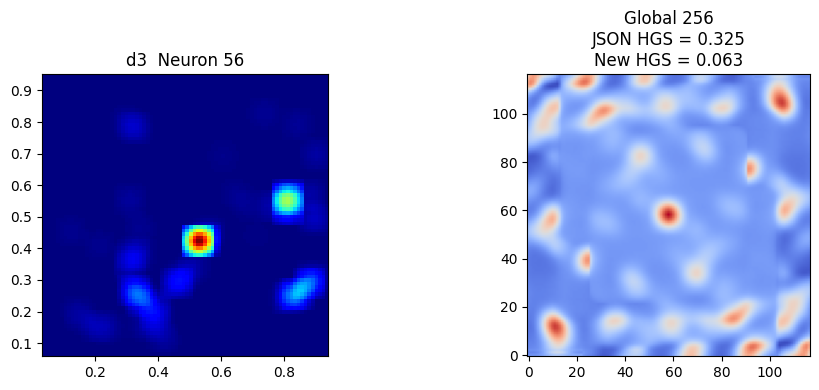

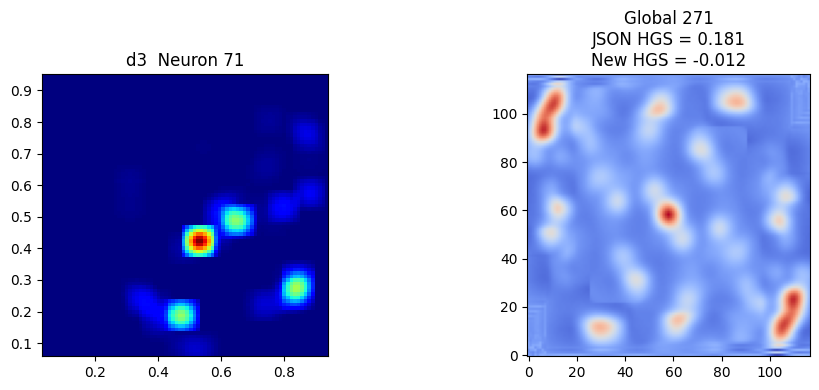

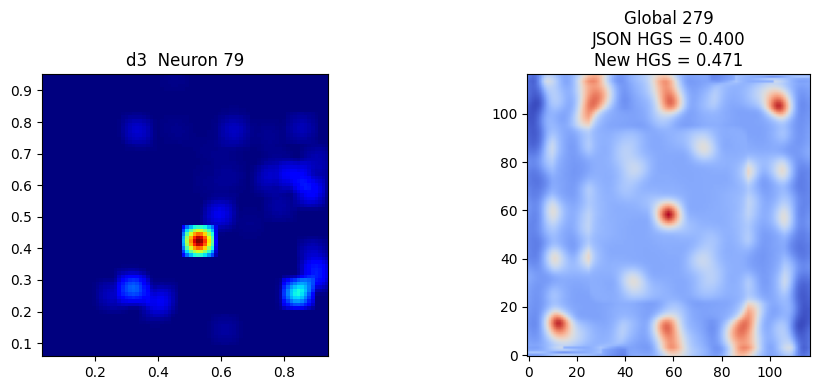

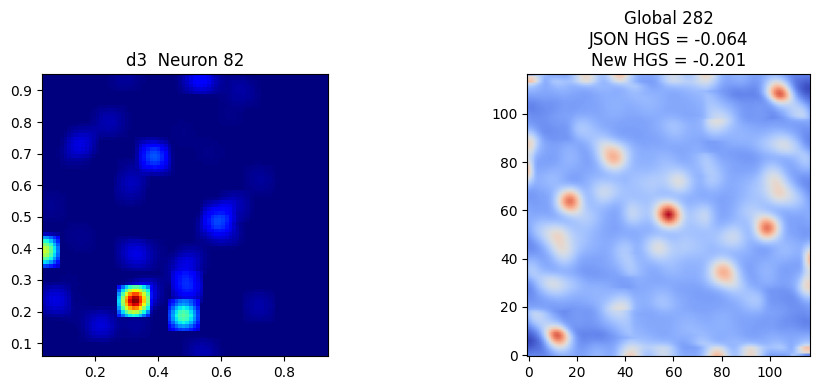

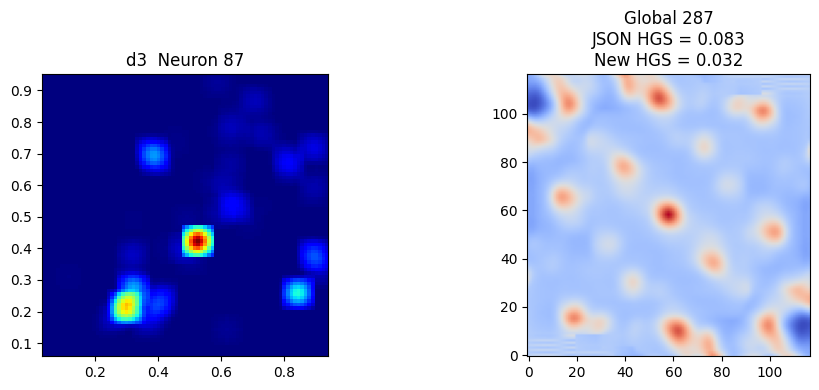

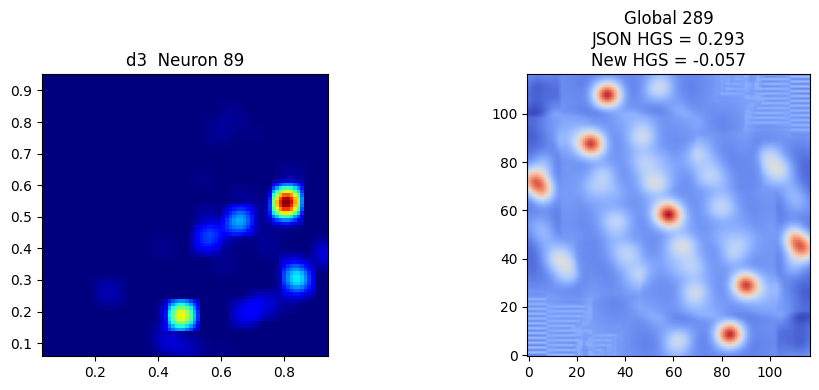

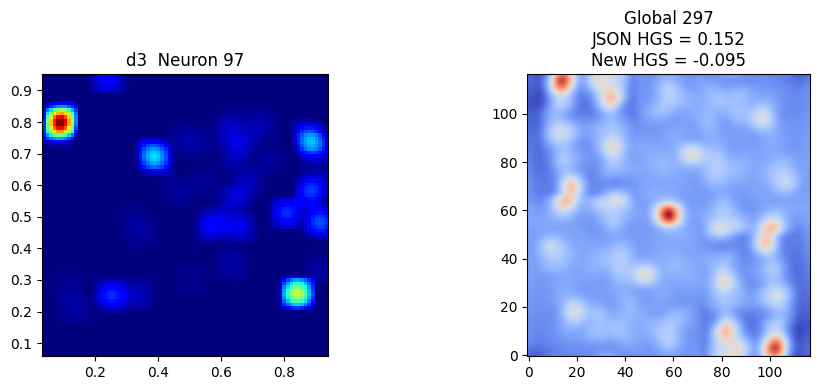

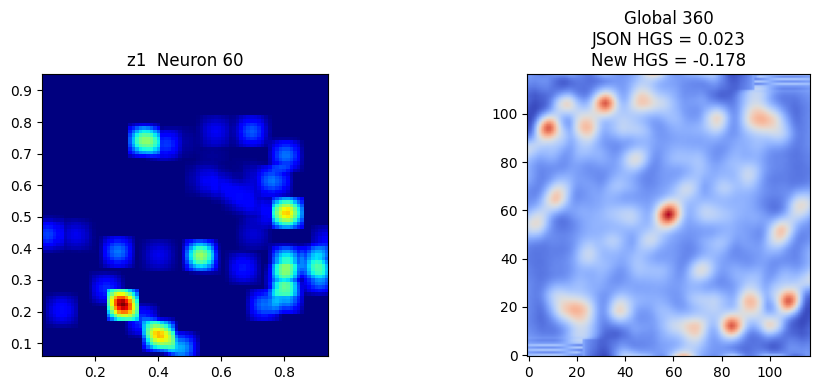

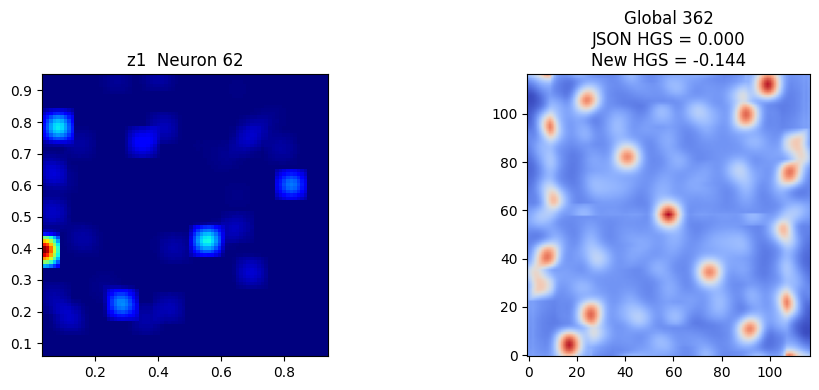

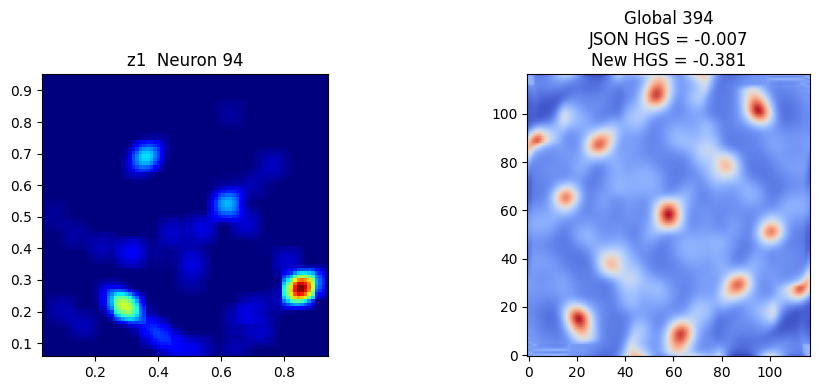

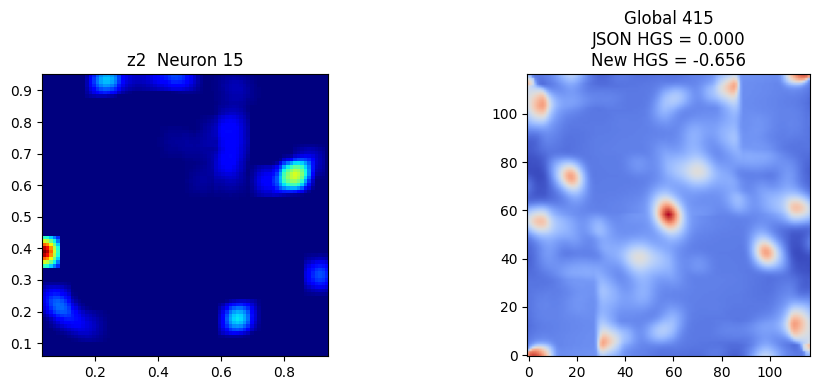

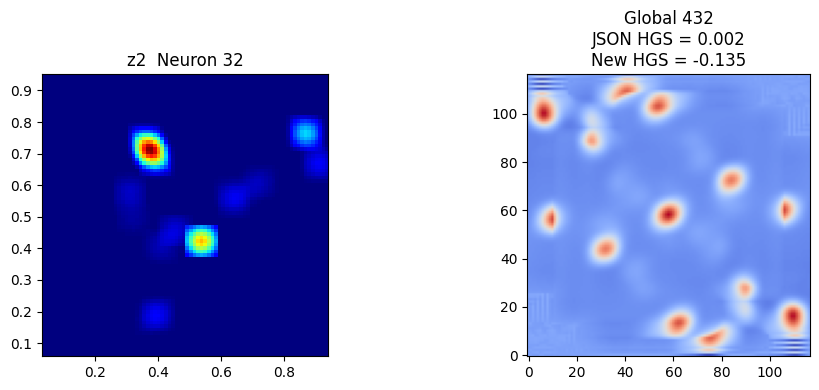

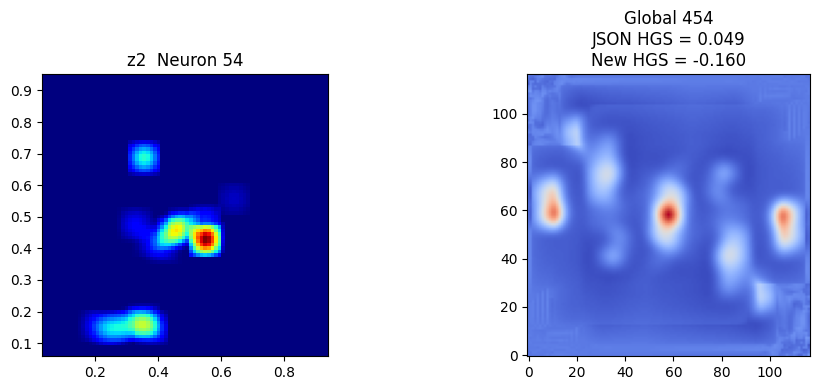

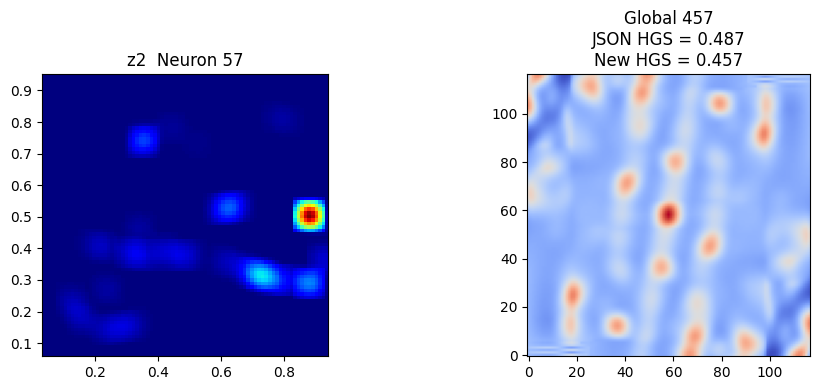

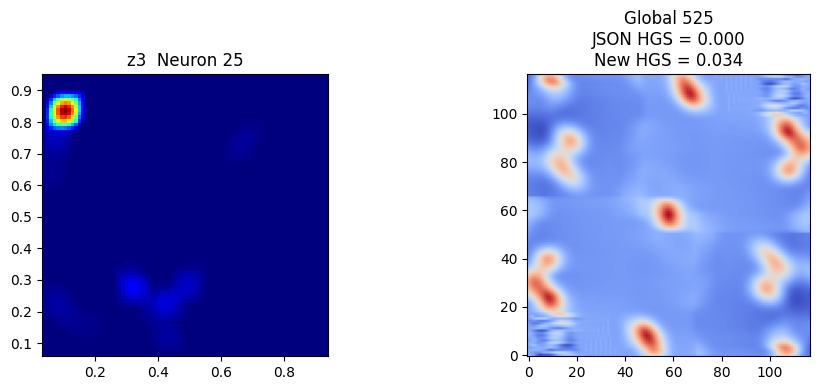

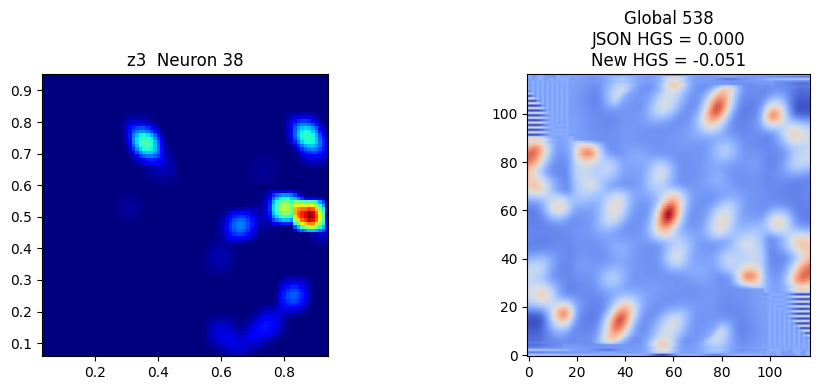

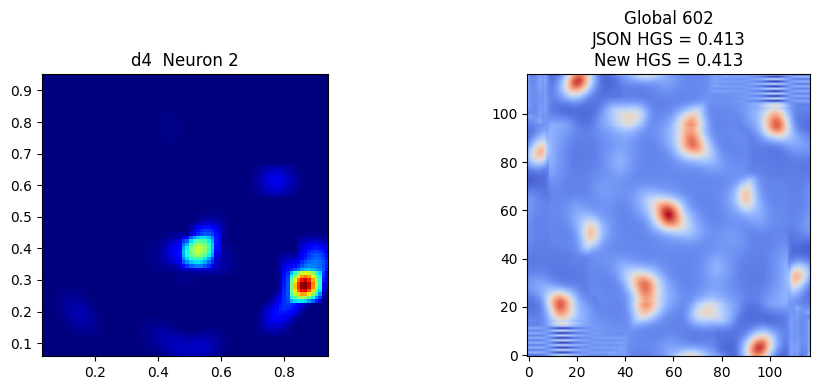

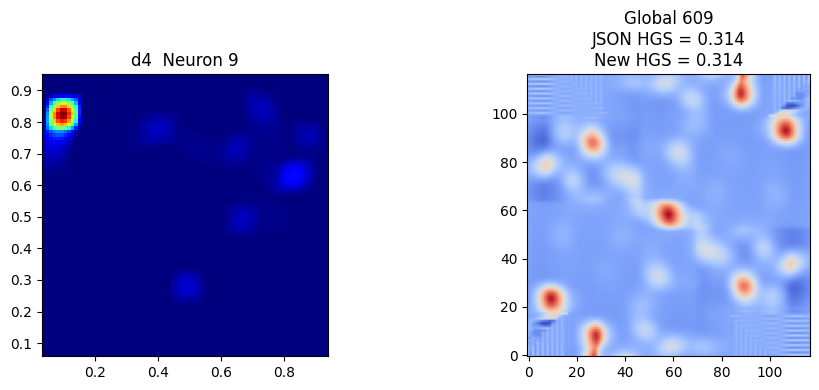

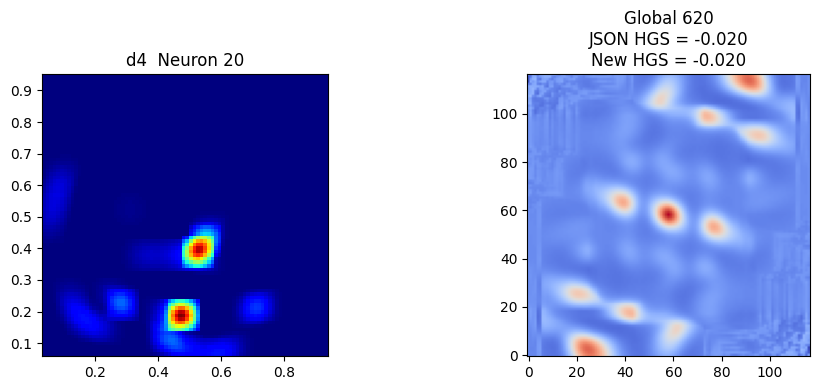

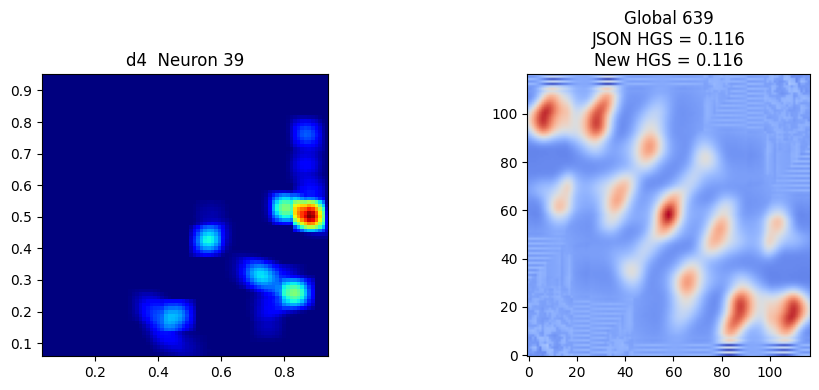

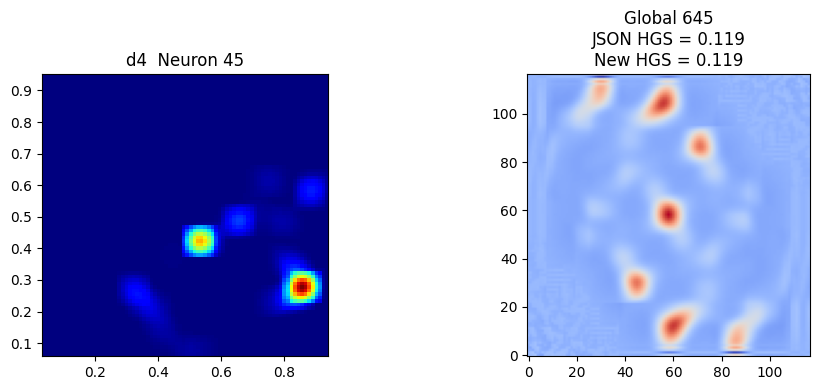

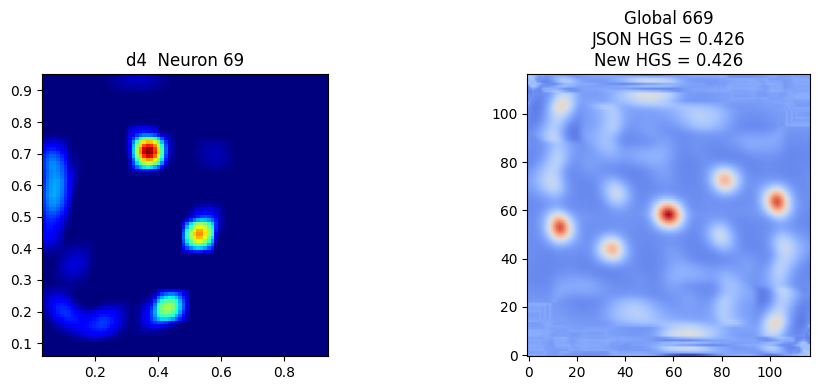

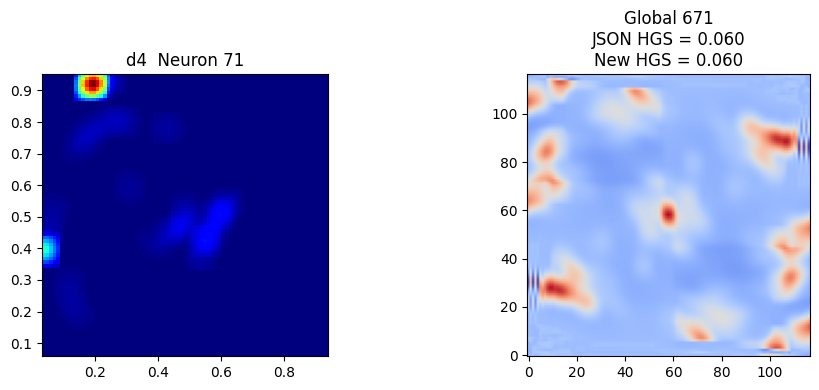

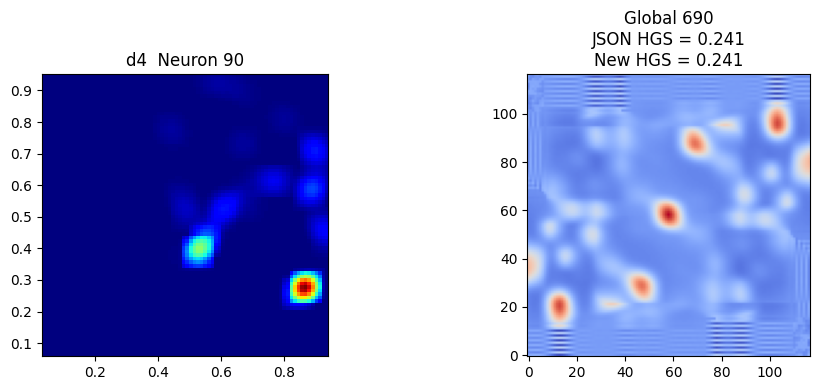

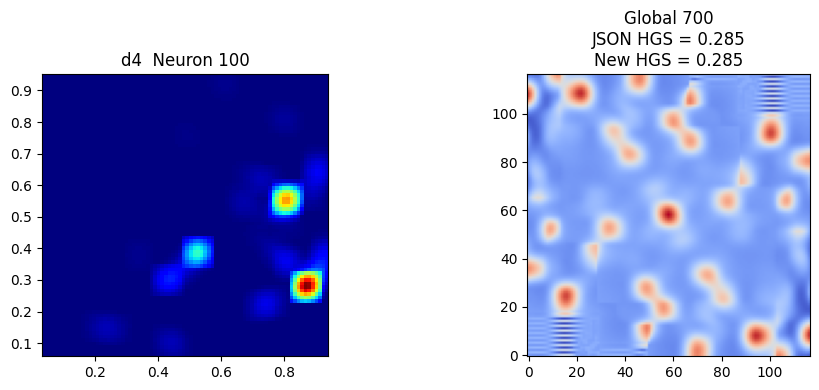

In [69]:
# ============================================================
# VISUALIZE ALL DETECTED GRID CELLS
# ============================================================

for global_idx in grid_results["grid_cell_indices"]:

    info = lookup[global_idx]

    # --------------------------------------------------------
    # Get neuron responses
    # --------------------------------------------------------

    responses = encoded_data[
        info["layer"]
    ][:, info["neuron_idx"]]

    # --------------------------------------------------------
    # Firing-rate map
    # --------------------------------------------------------

    firing_map, extent = firing_rate_map_grid(
        ot=responses,
        all_dat=trajectory,
        occupancy_map=occupancy_map,
        thresh_param=1.5,
    )

    # --------------------------------------------------------
    # Spatial autocorrelation
    # --------------------------------------------------------

    autocorr_map, autocorr_ring, radius = build_autocorrelation_ring(
        firing_map
    )

    # --------------------------------------------------------
    # Grid score (recomputed)
    # --------------------------------------------------------

    new_hgs = gridscore(autocorr_ring)

    # --------------------------------------------------------
    # Display
    # --------------------------------------------------------

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    ax[0].imshow(
        firing_map,
        origin="lower",
        extent=extent,
        cmap="jet",
    )

    ax[0].set_title(
        f"{info['layer']}  Neuron {info['neuron_idx']+1}"
    )

    ax[1].imshow(
        autocorr_map,
        origin="lower",
        cmap="coolwarm",
    )

    ax[1].set_title(
        f"Global {global_idx}\n"
        f"JSON HGS = {info['hgs']:.3f}\n"
        f"New HGS = {new_hgs:.3f}"
    )

    plt.tight_layout()
    plt.show()